In [18]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

sys.version_info(major=3, minor=9, micro=13, releaselevel='final', serial=0)
matplotlib 3.8.4
numpy 1.26.4
pandas 2.2.1
sklearn 1.4.2
torch 2.8.0+cpu
cpu


# 数据准备

In [28]:
from torchvision import datasets
from torchvision import transforms

# 定义数据集的变换
transform = transforms.Compose([
    transforms.ToTensor()  # 将原数据转换成tensor类型的数据并且会自动进行归一化处理
])

# fashion_mnist图像分类数据集，衣服分类，60000张训练图片，10000张测试图片
train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform  # 需要转换成tensor
)

test_ds = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)


In [20]:
img,label =train_ds[0]
img.shape

torch.Size([1, 28, 28])

In [21]:
type(img)

torch.Tensor

In [22]:
img[0]

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510, 0.2863, 0.0000,
         0.0000, 0.0039, 0.0157, 0.0000, 0.0000, 0.0000

In [23]:
img

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [24]:
#计算均值和方差
def cal_mean_std(ds):
    mean = 0.
    std = 0.
    for img, _ in ds: # 遍历每张图片,img.shape=[1,28,28]
        mean += img.mean(dim=(1, 2))
        std += img.std(dim=(1, 2))
    mean /= len(ds)
    std /= len(ds)
    return mean, std


print(cal_mean_std(train_ds))

(tensor([0.2860]), tensor([0.3205]))


In [25]:
# 显示图片，这里需要把transforms.ToTensor()注释,进行归一化注释掉，否则是不行的
def show_img_content(img):
    from PIL import Image

    # 打开一个图像文件
    # img = Image.open(img)


    print("图像大小:", img.size)
    print("图像模式:", img.mode)


    # 如果图像是单通道的，比如灰度图，你可以这样获取像素值列表：
    if img.mode == 'L':
        pixel_values = list(img.getdata())
        print(pixel_values)
show_img_content(img) #这里必须把上面的 transforms.ToTensor(), # 转换为tensor，进行归一化注释掉，否则是不行的

图像大小: <built-in method size of Tensor object at 0x00000213E670CF90>
图像模式: <built-in method mode of Tensor object at 0x00000213E670CF90>


TypeError: Invalid shape (1, 28, 28) for image data

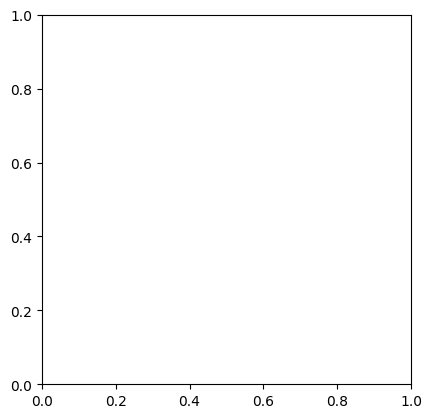

In [26]:
#这个代码必须是注释了上面的 transforms.ToTensor()才能够运行的
def show_single_image(img_arr):
    plt.imshow(img_arr, cmap="binary") # 显示图片，根据每个像素点的值将图片绘制出来
    plt.colorbar() # 显示颜色条
    plt.show()


show_single_image(img)

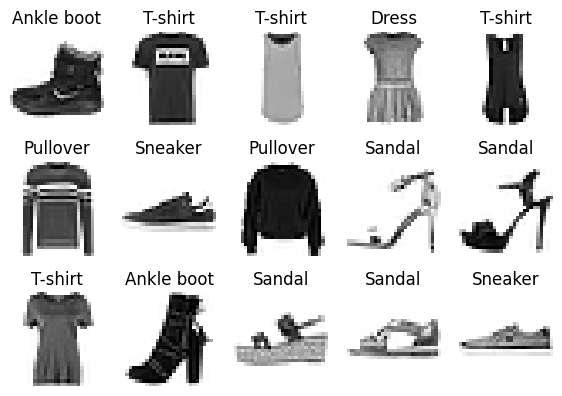

In [27]:
def show_imgs(n_rows, n_cols, train_ds, class_names):
    assert n_rows * n_cols < len(train_ds)  #确保打印的图片小于总样本数
    plt.figure(figsize = (n_cols * 1.4, n_rows * 1.6))  #宽1.4高1.6，宽，高
    for row in range(n_rows):
        for col in range(n_cols):
            index = n_cols * row + col  # 计算索引，从0开始
            plt.subplot(n_rows, n_cols, index+1)#因为从1开始
            img_arr, label = train_ds[index]
            img_arr = np.transpose(img_arr, (1, 2, 0))  # 通道换到最后一维，inshow要求宽和高在前面两维，样本数在最后一维
            plt.imshow(img_arr, cmap="binary",
                       interpolation = 'nearest')#interpolation='nearest'是临近插值
            plt.axis('off')#去除坐标系
            plt.title(class_names[label]) # 显示类别名称
    plt.show()



#已知的图片类别
# lables在这个路径https://github.com/zalandoresearch/fashion-mnist
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress',
               'Coat', 'Sandal', 'Shirt', 'Sneaker',
               'Bag', 'Ankle boot'] #0-9分别代表的类别
#只是打印了前15个样本
show_imgs(3, 5, train_ds, class_names)

In [29]:
# 从数据集到dataloader
train_loader =torch.utils.data.DataLoader(train_ds,batch_size=32,shuffle = True)
# batch分批，shuffle洗牌
val_loader =torch.utils.data.DataLoader(test_ds,batch_size = 32,shuffle=False)

# 定义模型

In [30]:
class NeuralNetwork(nn.Module):  # nn.Module是所有神经网络的基类，只要写模型基本都要去继承该类
    def __init__(self):
        super().__init__() # 继承父类的初始化方法，子类有父类的属性
        self.flatten = nn.Flatten()  # 展平层
        self.linear_relu_stack = nn.Sequential(  # sequential的作用是将多个网络层按照顺序连接起来
            nn.Linear(784, 300),  # in_features=784, out_features=300, 784是输入特征数，300是输出特征数
            nn.ReLU(), # 激活函数
            nn.Linear(300, 100),#隐藏层神经元数100
            nn.ReLU(), # 激活函数
            nn.Linear(100, 10),#输出层神经元数10
        )

    def forward(self, x): # 前向计算
        # x.shape [batch size, 1, 28, 28]  # 1为图片通道数量（灰度图片）
        x = self.flatten(x)  # 对象加括号是默认调用内置方法
        # 展平后 x.shape [batch size, 784]
        logits = self.linear_relu_stack(x)
        # logits.shape [batch size, 10]
        return logits #没有经过softmax,范围仍然是负无穷到正无穷称为logits

model = NeuralNetwork()

In [31]:
# 观察网络结构
model

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=300, bias=True)
    (1): ReLU()
    (2): Linear(in_features=300, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)

# 训练
pytorch的训练需要自行实现，包括
    1.定义损失函数
    2.定义优化器
    3.定义训练步
    4.训练

In [35]:
# 定义损失函数 采用交叉熵损失，用来衡量模型预测概率分布和真实标签之间差距的函数，预测越准确，损失就越小
"""
CrossEntropyLoss = Softmax + Log + NLLLoss
先做softmax将模型输出的logits(任意实数)转换成概率分布,然后再对softmax产生的数求log取反
"""
loss_fct = nn.CrossEntropyLoss()

"""
Optimizers specified in the torch.optim package,随机梯度下降w = w - lr * gradient
momemtum 动量，梯度加上之前的梯度，可以加快收敛速度
训练的通常流程：前向传播 → 计算损失 → 反向传播 → 优化器更新参数
"""
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [36]:
from sklearn.metrics import accuracy_score

"""
evaluating函数用于评估模型在验证集上的性能
"""

def evaluating(model, dataloader, loss_fct):
    loss_list = [] # 每个组别的损失值
    pred_list = [] # 记录预测
    label_list = [] # 记录标签
    for datas, labels in dataloader:  # 从dataLoader按照batch读入数据，一组32个数据
        datas = datas.to(device) # 转到GPU，将张量送入gpu或cpu中
        labels = labels.to(device) # 转到GPU

        # 前向计算
        logits = model(datas)  # 将数据输入神经网络，得到预测结果
        loss = loss_fct(logits, labels)      # 用前面定义的损失函数计算损失
        loss_list.append(loss.item()) # 记录损失，item是将tensor标量转为数值 例：tensor(0.54)→ 0.54

        preds = logits.argmax(axis=-1)    # 验证集预测,argmax返回最大值索引，
        # print(preds)
        pred_list.extend(preds.cpu().numpy().tolist())#将PyTorch张量转换为NumPy数组。只有当张量在CPU上时，这个转换才是合法的
        # print(preds.cpu().numpy().tolist())
        label_list.extend(labels.cpu().numpy().tolist())

    acc = accuracy_score(label_list, pred_list) # 计算准确率：Accuracy = 正确预测数 / 总样本数
    return np.mean(loss_list), acc

In [37]:
# 训练
# eval_step是每多少步进行一次验证
def training(model, train_loader, val_loader, epoch, loss_fct, optimizer, eval_step=500):
    # train和val记录训练过程中损失和准确率
    record_dict = {
        "train": [],
        "val": []
    }

    global_step = 0  # 记录当前的步数，用来判别当前是否进行验证
    model.train() # 将模型设置为训练模式
    # tqdm是一个进度条库
    with tqdm(total=epoch * len(train_loader)) as pbar: # 进度条 1875*20,60000/32=1875
        for epoch_id in range(epoch): # 训练epoch次
            # training
            for datas, labels in train_loader: #执行次数是60000/32=1875
                datas = datas.to(device) #datas尺寸是[batch_size,1,28,28]
                labels = labels.to(device) #labels尺寸是[batch_size]
                # 梯度清空,pytorch中梯度是累加的，所以每次训练前要清空梯度
                optimizer.zero_grad()
                # 模型前向计算
                logits = model(datas)
                # 计算损失
                loss = loss_fct(logits, labels)
                # 根据计算图自动求导 计算 loss 对模型参数的梯度,loss.bakcward()是用来计算梯度的
                loss.backward()
                # 调整优化器，优化器的学习率会随着训练的进行而减小，更新w,b,w = w - lr * gradient
                optimizer.step()

                preds = logits.argmax(axis=-1) # 训练集预测
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())   # 计算准确率，numpy可以
                loss = loss.cpu().item() # GPU tensor → CPU → Python数值
                # record

            # 记录训练集信息，每一步的损失，准确率，步数
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                })

                # evaluating
                if global_step % eval_step == 0:
                    model.eval() # 进入评估模式
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train() # 进入训练模式

                # udate step
                global_step += 1 # 全局步数加1
                pbar.update(1) # 更新进度条
                pbar.set_postfix({"epoch": epoch_id}) # 设置进度条显示信息

    return record_dict


epoch = 20 #改为40
model = model.to(device)
record = training(model, train_loader, val_loader, epoch, loss_fct, optimizer, eval_step=1000)

  0%|          | 0/37500 [00:00<?, ?it/s]

In [41]:
record["train"][-5:]

[{'loss': 0.18562625348567963, 'acc': 0.96875, 'step': 37495},
 {'loss': 0.40190374851226807, 'acc': 0.90625, 'step': 37496},
 {'loss': 0.4400333762168884, 'acc': 0.875, 'step': 37497},
 {'loss': 0.3335508108139038, 'acc': 0.84375, 'step': 37498},
 {'loss': 0.5348488092422485, 'acc': 0.78125, 'step': 37499}]

In [42]:
record["val"][-5:]

[{'loss': 0.3636702981096106, 'acc': 0.8702, 'step': 33000},
 {'loss': 0.3711551992823712, 'acc': 0.8701, 'step': 34000},
 {'loss': 0.3537166194674877, 'acc': 0.8745, 'step': 35000},
 {'loss': 0.3597947745658338, 'acc': 0.8733, 'step': 36000},
 {'loss': 0.3619285093757291, 'acc': 0.8697, 'step': 37000}]

step
0        0.15625
1000     0.93750
2000     0.84375
3000     0.87500
4000     0.87500
5000     0.93750
6000     0.87500
7000     0.78125
8000     0.87500
9000     0.87500
10000    0.84375
11000    0.84375
12000    0.96875
13000    0.93750
14000    0.87500
15000    0.87500
16000    0.96875
17000    0.84375
18000    0.93750
19000    0.90625
20000    0.84375
21000    0.90625
22000    0.84375
23000    0.87500
24000    0.90625
25000    0.90625
26000    0.87500
27000    0.81250
28000    0.90625
29000    0.87500
30000    0.93750
31000    0.87500
32000    0.87500
33000    0.87500
34000    0.96875
35000    0.87500
36000    0.93750
37000    0.78125
Name: acc, dtype: float64
step
0        0.1000
1000     0.6893
2000     0.7636
3000     0.7862
4000     0.7985
5000     0.8242
6000     0.8232
7000     0.8257
8000     0.8308
9000     0.8328
10000    0.8398
11000    0.8402
12000    0.8444
13000    0.8451
14000    0.8498
15000    0.8495
16000    0.8501
17000    0.8545
18000    0.8572
19000    0.858

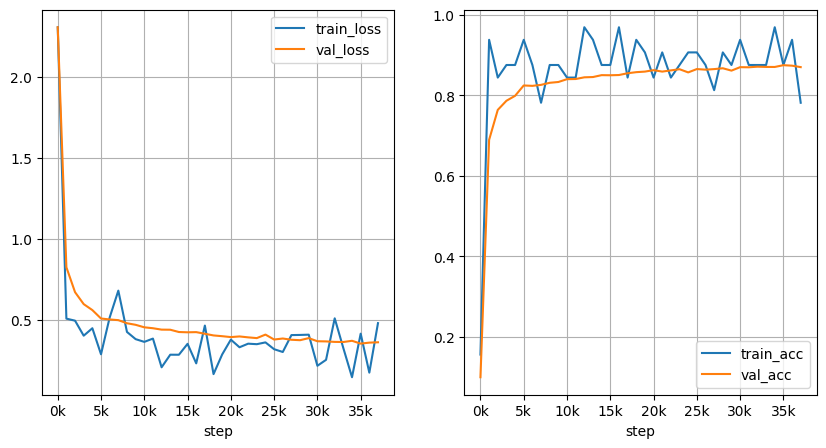

In [38]:
#画线要注意的是损失是不一定在零到1之间的
def plot_learning_curves(record_dict, sample_step=1000):
    # build DataFrame
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")
    last_step = train_df.index[-1] # 最后一步的步数
    # print(train_df.columns)
    print(train_df['acc'])
    print(val_df['acc'])
    # plot
    fig_num = len(train_df.columns) # 画几张图,分别是损失和准确率
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):
        # print(train_df[item].values)
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[idx].grid() # 显示网格
        axs[idx].legend() # 显示图例
        axs[idx].set_xticks(range(0, train_df.index[-1], 5000)) # 设置x轴刻度
        axs[idx].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, last_step, 5000))) # 设置x轴标签
        axs[idx].set_xlabel("step")

    plt.show()

plot_learning_curves(record)  #横坐标是 steps

# 评估

In [39]:
model.eval() # 进入评估模式
loss, acc = evaluating(model, val_loader, loss_fct)
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     0.3513
accuracy: 0.8748
